In [1]:
import os
import sys

import json
import random
import time
import pandas as pd
import seaborn as sns

from datetime import datetime
from dotenv import load_dotenv
from pathlib import Path

In [ ]:
MODULES_PATH = Path("../modules").resolve()

if str(MODULES_PATH) not in sys.path:
    sys.path.insert(0, str(MODULES_PATH))

import corpus
import api

from dev import rel, print_epi_summary
from data_config import DATA_CONFIG, FEW_SHOT_PATH
from few_shot import get_few_shot_examples
from error_sampling import error_summary, sample_errors
from plotting import plot_dist_comparison

import pipeline

# Config.

### Development Config.

In [3]:
load_dotenv()

# ---------- Set seed to 42 ----------
SEED = int(os.getenv("SEED", 42))
random.seed(SEED)

# ---------- Print confirmation ----------
print(
    f"Set random seed to {SEED} at "
    f"{datetime.now().strftime('%Y-%m-%d %H:%M')}"
)

Set random seed to 42 at 2026-08-10 07:23


### EPI Config.

ADD FUNCTIONALITY IN CELL BELOW THAT BREAKS IF EXPORTED EPI_LOG FOR `EPI_NUM` DOES NOT EXIST SO THAT NON-EXISTENT RUN IS NOT PROCESSED

In [548]:
# ---------- Manual EPI config. entry ----------
EPI_NUM = "008"
DATASET_SPLIT = "train"

# ---------- Config. whether EPI config's API should be called again ----------
CALL_API = True

# ---------- Config. whether error distribution figure should be saved ----------
SAVE_FIG = True

# Corpus Loading

### Load Corpus

In [549]:
# ---------- Get abstracts path ----------
ABSTRACTS_PATH = DATA_CONFIG[DATASET_SPLIT]["paths"]["abstracts"]
SAMPLE_SIZE = DATA_CONFIG[DATASET_SPLIT]["sample_size"]

# ---------- Load corpus from path ----------
abstracts_corpus = corpus.load_corpus(ABSTRACTS_PATH, sample_size=SAMPLE_SIZE)
print(f"Abstracts dataset length: {len(abstracts_corpus)}")

Abstracts dataset length: 35


### Get Ground Truths

In [550]:
# ---------- Manually Set Ground Truth Path ----------
GT_PATH = DATA_CONFIG[DATASET_SPLIT]["paths"]["ground_truths"]

# ---------- Fetch BioRED Ground Truths ----------
abstracts_ground_truths = corpus.get_corpus_gt_csv(abstracts_corpus, GT_PATH)

In [551]:
# ---------- Turn ground truth DataFrame into structured dict ----------
ground_truths = corpus.get_gt_dict(abstracts_ground_truths)

In [552]:
import pandas as pd
gt_df = pd.DataFrame(list(ground_truths["relations"]))
print(list(gt_df[2].unique()))

['Negative_Correlation', 'Association', 'Positive_Correlation', 'Bind', 'Comparison']


### Few-Shot Construction

In [553]:
# ---------- If FS block does not exist, create FS block, else pass ----------
if not os.path.exists(FEW_SHOT_PATH):

    few_shot_block = get_few_shot_examples(
        path_to_train_set=DATA_CONFIG["train"]["paths"]["abstracts"],
        path_to_train_gts=DATA_CONFIG["train"]["paths"]["ground_truths"],
        biored_train_samples=abstracts_corpus,
        few_shot_export_path=FEW_SHOT_PATH
    )
    print(f"Generated and exported new few-shot block to '{FEW_SHOT_PATH}'")
else:
    with open(FEW_SHOT_PATH) as f:
        few_shot_block = f.read()
    print(f"Imported existing few-shot block from '{FEW_SHOT_PATH}' at {datetime.now().strftime('%Y-%m-%d %H:%M')}.")

Imported existing few-shot block from '../../data/few_shot/few_shot_block.txt' at 2026-08-10 20:47.


### Import BioRED Extraction Guidelines

In [554]:
# ---------- Import BioRED guidelines text file for prompt refinement ----------
with open("../../data/processed/biored/guidelines.txt", "r", encoding="utf-8") as f:
    biored_ext_guidelines = f.read()

# ---------- Print preview ----------
print(f"{biored_ext_guidelines[:500]}...")

## Guideline of the entities

### General rules
- Annotate all the spans of all the six concept types.
- The full text can be accessed to clarify the concept spans and identifiers.
- The abbreviation and its long form should be annotated separately if possible. prostaglandin E2 (PGE2) in the text, “prostaglandin E2” and “PGE2” should be both annotated to chemicals with the same identifier (D015232).
- Annotate both the full name and abbreviation in one entity, if the boundary of the entity cover...


# OpenAI Luna API Call

### EPI Setup

In [555]:
# ---------- Create EPI setup dictionary ----------
# - Keys: "dataset", "id", "eval_version", "notes", "reuse_api_call", "prompt"
epi_setup = pipeline.setup_epi(EPI_NUM, DATASET_SPLIT)

# ---------- Print summary ----------
print_epi_summary(
    epi_num=EPI_NUM,
    prompt_version=epi_setup["prompt"]["version"],
    eval_version=epi_setup["eval_version"],
    notes=epi_setup["notes"],
    reuse_api_call=epi_setup["reuse_api_call"]
)

Cell ran at 2026-08-10 20:47 for epi_008
 - Prompt version: v5
 - Evaluation version: v4
 - Notes: Refined prompt for explicit prevention of unsupported specific relationship inference.
 - Reuse API Call: False


### API Call

In [556]:
if CALL_API:
    # ---------- Create client ----------
    client = api.create_client()

    # ---------- If prompt version is different from previous EPI, call API, else pass ----------
    if not epi_setup["reuse_api_call"]:

        print(f"Running API call for {epi_setup["id"]}...")

        # Fetch raw prompt template
        prompt_template = epi_setup["prompt"]["template"]

        # Begin timer
        start_time = time.perf_counter()

        # Initiate outputs list
        outputs = []

        # Begin looping through abstract dataset rows - one call per row
        for index, row in abstracts_corpus.iterrows():
            abstract = row["abstract"]

            # Replace prompt template's placeholders with abstract, few_shot & guidelines
            prompt = (
                prompt_template
                .replace("{abstract}", abstract)
                .replace("{few_shot_block}", few_shot_block)
                .replace("{biored_ext_guidelines}", biored_ext_guidelines)
            )

            # Store row's response
            response = client.responses.create(
                model="gpt-5.6-luna",
                input=prompt
            )

            # Append response to outputs list
            outputs.append({
                "pmid": row["pmid"],
                "output": response.output_text
            })

        # End time, store elapsed time & print result
        elapsed_seconds = time.perf_counter() - start_time
        print(f"API calls took {elapsed_seconds:.1f}s ({elapsed_seconds/60:.1f} min) for {len(outputs)} abstracts\n")

        print(f"Successfully ran API call at {datetime.now().strftime('%Y-%m-%d %H:%M')}")
        print(f" - Prompt verion: {epi_setup["prompt"]["version"]}")
        print(f" - Evalaution verion: {epi_setup["eval_version"]}")
        print(f" - Run notes: {epi_setup["notes"]}")
        print(f" - Elapsed time: {elapsed_seconds:.1f}s ({elapsed_seconds/60:.1f}")
    else:
        prev_epi_id = f"epi_{int(EPI_NUM) - 1:03d}"

        with open(f"{DATA_CONFIG[DATASET_SPLIT]["paths"]["epis"]}/{prev_epi_id}.json") as f:
            prev_epi_log = json.load(f)

        outputs = prev_epi_log["outputs"]
        prompt_template = prev_epi_log["prompt"]
        elapsed_seconds = prev_epi_log["time_taken"]

        print(f"Reused API call from {prev_epi_id}.")

    output_info = {
        "epi_id": epi_setup["id"],
        "outputs": outputs,
        "time_taken": elapsed_seconds,
        "raw_prompt": prompt_template,
        "epi_notes": epi_setup["notes"],
        "prompt_version": epi_setup["prompt"]["version"],
        "eval_version": epi_setup["eval_version"],
        "export_path": DATA_CONFIG[DATASET_SPLIT]["paths"]["epis"]
    }
else:
    print(f"Pipeline run not executed at {datetime.now().strftime('%Y-%m-%d %H:%M')} (PIPELINE_RUN = False).")

Created client:
 - Timeout: 60
 - Max retries: 0

Running API call for epi_008...
API calls took 712.3s (11.9 min) for 35 abstracts

Successfully ran API call at 2026-08-10 20:59
 - Prompt verion: v5
 - Evalaution verion: v4
 - Run notes: Refined prompt for explicit prevention of unsupported specific relationship inference.
 - Elapsed time: 712.3s (11.9


In [557]:
# ---------- Parse outputs, evaluate extractions, export EPI results ----------
if CALL_API:
    epi_log = pipeline.process_epi(output_info, ground_truths, dataset=epi_setup["dataset"])
else:
    print(f"Pipeline run not executed at {datetime.now().strftime('%Y-%m-%d %H:%M')} (CALL_API = False).")

Parsed 35 extractions, 0 failed to parse as JSON


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Saved epi_008 to ../../data/results/epis/biored_train


# Error Analysis

### Summary Table

In [559]:
# ---------- If EPI API call does not exist in kernel state, import existing EPI log ----------
if not CALL_API:
    try:
        with open(f"../../data/results/epis/{epi_setup["dataset"]}/{epi_setup["id"]}.json") as f:
            epi_log = json.load(f)
    except:
        raise ValueError(
            f"EPI log cannot be imported: "
            f"'../../data/results/epis/{epi_setup["dataset"]}/{epi_setup["id"]}.json' does not exist."
        )

error_summary(epi_log)

`epi_008` Error Summary:


Metric,Precision,Recall,F1
Entity,0.572,0.949,0.714
Relation,0.512,0.591,0.549


### Distribution Comparison

Saved figure to `../../img/epi_008_gt_ext_dist` successfully.


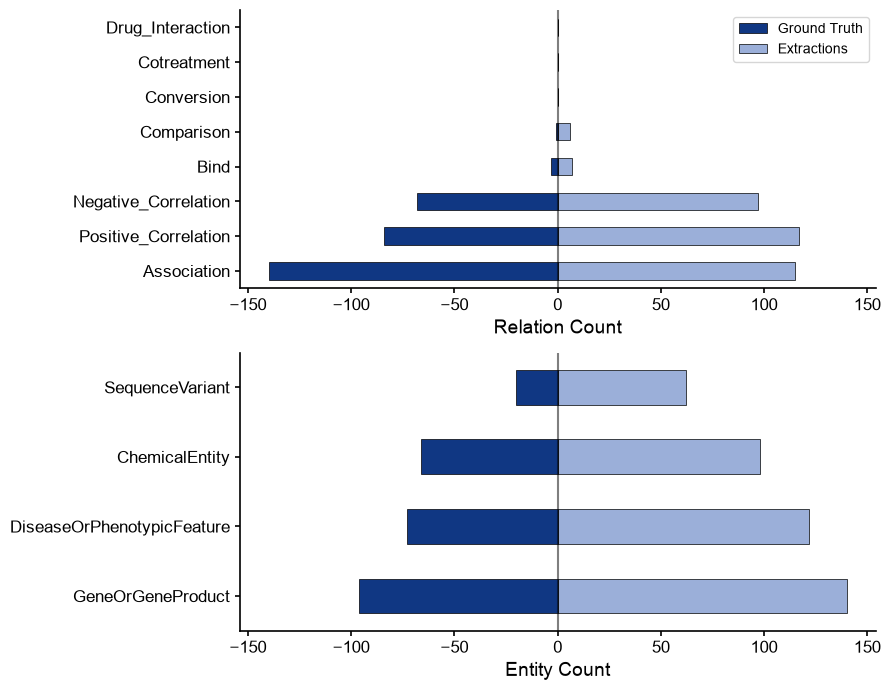

In [560]:
if EPI_NUM != "001" and epi_setup["reuse_api_call"] == False:
    plot_dist_comparison(epi_log, ground_truths, save=SAVE_FIG)
else:
    print(f"Did not plot ground truth/extraction distribution figure for `epi_{EPI_NUM}`.")

## Relations

### False Positives

In [569]:
# ---------- False positives ----------
relation_fp = epi_log["errors"]["errors"]["relations"]["false_positives"]

print(f"Count: {len(relation_fp)}")

sample_errors(relation_fp, sample_size=20)

Count: 167
Sample size: 20


[[24914936, 't4', 'Positive_Correlation', 'bone stiffness and strength'],
 [15970799, 'slco1b1*15', 'Negative_Correlation', 'pravastatin'],
 [15970799, 'slco1b1*15', 'Negative_Correlation', 'atorvastatin'],
 [19108278,
  '(-)-propranolol',
  'Negative_Correlation',
  'ventricular tachycardia'],
 [19319147, 'warfarin', 'Positive_Correlation', 'w-ich'],
 [19521089, 'slc6a4', 'Association', 'rs25531'],
 [28428256,
  'thrombin receptor-activating peptide',
  'Positive_Correlation',
  'acute lung injury'],
 [19108278, '(+)-propranolol', 'Negative_Correlation', 'isoprenaline'],
 [20431083, 'mb', 'Positive_Correlation', 'ich'],
 [19319147,
  'warfarin',
  'Positive_Correlation',
  'warfarin-associated intracerebral hemorrhage'],
 [28428256, 'pga2', 'Positive_Correlation', 'rap1/rac1 gtpase'],
 [18827003, 'hgr', 'Association', 'metabolic syndrome'],
 [19918264, 'arg allele', 'Association', 'prostate cancer'],
 [29222418, 'heb', 'Positive_Correlation', 'rorgt'],
 [19891556,
  'variant allele',


### False Negatives

In [ ]:
# ---------- False negatives ----------
relation_fn = epi_log["errors"]["errors"]["relations"]["false_negatives"]

print(f"Count: {len(relation_fn)}")

sample_errors(relation_fn, sample_size=20)

Count: 121
Sample size: 20


[[24341598, 'diltiazem', 'Negative_Correlation', 'nephropathy'],
 [28411266, 'sulfonylurea receptor', 'Association', 'coronary heart disease'],
 [25305591,
  'experimental autoimmune encephalomyelitis',
  'Association',
  'vasoactive intestinal peptide'],
 [10491763, 'glucose', 'Association', 'type ii diabetes'],
 [29222418, 'heb', 'Negative_Correlation', 'id3'],
 [18768591,
  'serum- and glucocorticoid-inducible kinase 1',
  'Association',
  'doxorubicin'],
 [28428256, 'ep4', 'Positive_Correlation', 'rap1/rac1 gtpase'],
 [28348168, 'degenerative disease', 'Association', 'fgfr2'],
 [28512644, 'g7958', 'Association', 'erysipelas'],
 [15970799, 'tritium', 'Association', 'estrone-3-sulfate'],
 [19319147, 'warfarin', 'Association', 'intracerebral hemorrhage'],
 [15970799, 'tritium', 'Association', 'estradiol-17beta-d-glucuronide'],
 [24477591, 'reactive oxygen species', 'Association', 'atherosclerosis'],
 [28512644, 'ccl2', 'Association', 'cat'],
 [24309294, 'cck1 receptor', 'Negative_Corr

## Entities

### False Positives

In [563]:
# ---------- False positives ----------
entities_fp = epi_log["errors"]["errors"]["entities"]["false_positives"]

print(f"Count: {len(entities_fp)}")

sample_errors(entities_fp)

Count: 181
Sample size: 20


[[24743235, 'il-3', 'GeneOrGeneProduct'],
 [21163864, 'shcm', 'DiseaseOrPhenotypicFeature'],
 [25305591,
  'pituitary adenylyl cyclase-activating polypeptide',
  'ChemicalEntity'],
 [19319147, 'hematomas', 'DiseaseOrPhenotypicFeature'],
 [28512644, 'bullous erysipelas', 'DiseaseOrPhenotypicFeature'],
 [20431083, 'tia', 'DiseaseOrPhenotypicFeature'],
 [19521089, '5-httlpr/rs25531', 'SequenceVariant'],
 [16200390, '5-hydroxytryptamine', 'ChemicalEntity'],
 [25305591, 'mog35-55', 'ChemicalEntity'],
 [10491763, 'type ii diabetes mellitus', 'DiseaseOrPhenotypicFeature'],
 [16574712, '3,4-methylenedioxymethamphetamine', 'ChemicalEntity'],
 [28428256, 'pga2', 'ChemicalEntity'],
 [16120104, 'asps', 'DiseaseOrPhenotypicFeature'],
 [20431083, 'intracerebral hemorrhage', 'DiseaseOrPhenotypicFeature'],
 [25305591, 'vip', 'ChemicalEntity'],
 [20431083, 'ich', 'DiseaseOrPhenotypicFeature'],
 [16200390, 'insertion deletion', 'SequenceVariant'],
 [18808529, 'laminin', 'GeneOrGeneProduct'],
 [21771880,

### False Negatives

In [564]:
# ---------- False negatives ----------
entities_fn = epi_log["errors"]["errors"]["entities"]["false_negatives"]

print(f"Count: {len(entities_fn)}")

sample_errors(entities_fn)

Count: 13


[[25305591,
  'pituitary adenylyl cyclase-activating polypeptide',
  'GeneOrGeneProduct'],
 [24477591, 'obesity', 'DiseaseOrPhenotypicFeature'],
 [28428256, 'thrombin receptor', 'GeneOrGeneProduct'],
 [28348168, 'degenerative disease', 'DiseaseOrPhenotypicFeature'],
 [18808529, 'oxygen', 'ChemicalEntity'],
 [20683499, 'neurodegenerative diseases', 'DiseaseOrPhenotypicFeature'],
 [28411266, 'insulin', 'GeneOrGeneProduct'],
 [18768591, 'weight gain', 'DiseaseOrPhenotypicFeature'],
 [15970799, 'tritium', 'ChemicalEntity'],
 [15686794, 'antiarrhythmic drug', 'ChemicalEntity'],
 [28348168, 'cancer', 'DiseaseOrPhenotypicFeature'],
 [15099351, 'cholesterol', 'ChemicalEntity'],
 [20510337, 'lipid', 'ChemicalEntity']]